# Bug Report: Reproduction Tests

Testing claims that the croissant simulator:
1. Gets the first time wrong
2. Rotates the Moon the wrong way

**Setup:** A single healpix pixel (point source) sky, Gaussian beam (σ=20°), observer near the lunar equator. Each simulation spans one lunar sidereal day (~27.3 Earth days).

**Approach:** Work directly with JAX arrays and standalone functions (no `Beam`, `Sky`, `Simulator` objects).

In [1]:
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import s2fft
from lunarsky import LunarTopo, MoonLocation
from lunarsky import Time as LunarTime

from croissant.constants import sidereal_day
from croissant.rotations import generate_euler_dl
from croissant.simulator import convolve, rot_alm_z
from croissant.sphere import compute_alm
from croissant.utils import generate_phi, generate_theta

%matplotlib inline

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [2]:
# === Sky parameters ===
nside = 8
npix = 12 * nside**2  # 768
lmax = 2 * nside  # 16
freq = jnp.array([50.0])  # single frequency in MHz

# === Beam parameters ===
sigma_deg = 20.0
sigma = np.radians(sigma_deg)

# === Observer: near lunar equator ===
obs_lat = 5.0  # degrees
obs_lon = 0.0  # degrees

# === Time: one lunar sidereal day ===
T_sid = sidereal_day["moon"]  # seconds
N_times = 500
dt_sec = jnp.linspace(0, T_sid, N_times)
dt_days = np.array(dt_sec) / 86400

# Arbitrary start time (Julian Date)
t0_jd = 2460000.0

print(
    f"Lunar sidereal day: {T_sid / 3600:.1f} hours = {T_sid / 86400:.2f} days"
)
print(f"lmax = {lmax}, nside = {nside}, npix = {npix}")

Lunar sidereal day: 655.7 hours = 27.32 days
lmax = 16, nside = 8, npix = 768


## Create Sky and Beam

**Sky:** Single healpix pixel = 1 near the MCMF equator at ~60° east longitude. All other pixels = 0. Defined directly in MCMF coordinates (no galactic→MCMF rotation needed).

**Beam:** Azimuthally symmetric Gaussian with σ=20°, centered at zenith, on the `mwss` grid. Horizon-masked (only upper hemisphere).

In [3]:
# --- Point source sky (MCMF coordinates) ---
# Find healpix pixel nearest to (theta=90°, phi=60°)
theta_hp = generate_theta(sampling="healpix", nside=nside)
phi_hp = generate_phi(sampling="healpix", nside=nside)

target_theta = np.pi / 2  # equator
target_phi = np.pi / 3  # 60° east

cos_dist = np.sin(target_theta) * np.sin(theta_hp) * np.cos(
    phi_hp - target_phi
) + np.cos(target_theta) * np.cos(theta_hp)
angular_dist = np.arccos(np.clip(cos_dist, -1, 1))
source_pixel = int(np.argmin(angular_dist))
source_theta = theta_hp[source_pixel]
source_phi = phi_hp[source_pixel]

print(f"Source pixel: {source_pixel}")
print(
    f"Source position: theta = {np.degrees(source_theta):.1f}°, "
    f"phi = {np.degrees(source_phi):.1f}°"
)
print(
    f"Source MCMF lat = {90 - np.degrees(source_theta):.1f}°, "
    f"lon = {np.degrees(source_phi):.1f}°"
)

sky_data = jnp.zeros((1, npix))
sky_data = sky_data.at[0, source_pixel].set(1.0)

Source pixel: 373
Source position: theta = 90.0°, phi = 61.9°
Source MCMF lat = 0.0°, lon = 61.9°


In [4]:
# --- Gaussian beam on mwss grid ---
L = lmax + 1
theta_b = s2fft.sampling.s2_samples.thetas(L, sampling="mwss")
phi_b = s2fft.sampling.s2_samples.phis_equiang(L, sampling="mwss")
theta_grid, phi_grid = np.meshgrid(theta_b, phi_b, indexing="ij")

# Gaussian centered at zenith (theta=0)
beam_pattern = np.exp(-(theta_grid**2) / (2 * sigma**2))
beam_data = jnp.array(beam_pattern[None])  # shape (1, ntheta, nphi)

# Horizon mask: theta <= pi/2
horizon = theta_grid <= np.pi / 2
beam_above = beam_data * jnp.array(horizon[None])

# Beam normalization: integral of FULL beam over sphere (no horizon mask)
# This matches what Simulator.sim() does via Beam.compute_norm()
wgts = s2fft.utils.quadrature_jax.quad_weights(L=L, sampling="mwss")
beam_norm = jnp.einsum("ftp,t->f", beam_data, wgts)
print(f"Beam normalization (full sphere integral): {beam_norm}")

Beam normalization (full sphere integral): [0.73523706]


In [5]:
# --- Compute spherical harmonic coefficients ---
sky_alm = compute_alm(sky_data, lmax, "healpix", nside=nside, niter=3)
beam_alm_topo = compute_alm(beam_above, lmax, "mwss")

print(f"Sky alm shape: {sky_alm.shape}")
print(f"Beam alm shape: {beam_alm_topo.shape}")

Sky alm shape: (1, 17, 33)
Beam alm shape: (1, 17, 33)


In [6]:
def run_sim(
    obs_lat, obs_lon, t0_jd, sky_alm, beam_alm_topo, beam_norm, lmax, dt_sec
):
    """
    Run a visibility simulation using standalone functions.
    Mimics what Simulator.sim() does internally.
    """
    L = lmax + 1

    # 1. Compute topo→MCMF rotation at the observation start time
    loc = MoonLocation(obs_lon, obs_lat)
    t0 = LunarTime(t0_jd, format="jd")
    topo = LunarTopo(location=loc, obstime=t0)
    eul, dl = generate_euler_dl(lmax, topo, "mcmf")

    # 2. Rotate beam from topocentric to MCMF
    rot_fn = partial(
        s2fft.utils.rotation.rotate_flms,
        L=L,
        rotation=eul,
        dl_array=dl,
    )
    beam_mcmf = jax.vmap(rot_fn)(beam_alm_topo)

    # 3. Compute sky rotation phases
    phases = rot_alm_z(lmax, times=dt_sec)

    # 4. Convolve and normalize
    vis = convolve(beam_mcmf, sky_alm, phases)
    vis = vis / beam_norm[None, :]

    return jnp.real(vis), eul

## Test 1: Does the source rise and set?

With the observer at (lat=5°, lon=0°) and the source near the MCMF equator at lon≈60°, we expect:
- A peak when the source transits (passes through the beam center)
- Near-zero visibility when the source is far from the beam
- The source drifts westward in the observer's sky (Moon rotates eastward, like Earth)

**Predicted transit time:** The source needs to drift from φ_source to φ_observer. Since stars move westward (decreasing MCMF longitude over time), a source east of the observer transits at Δt = (φ_source − φ_observer) / ω, where ω = 2π/T_sidereal.

Predicted transit: 4.70 days
Actual peak:       4.71 days
Discrepancy:       0.01 days
Peak visibility:   0.016298


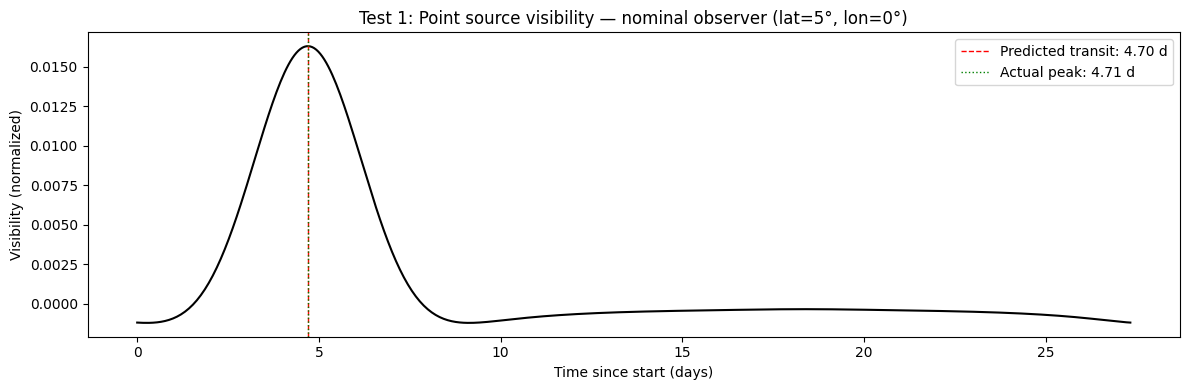

In [7]:
# Run nominal simulation
vis_nom, eul_nom = run_sim(
    obs_lat, obs_lon, t0_jd, sky_alm, beam_alm_topo, beam_norm, lmax, dt_sec
)

# Predicted transit: source drifts westward at rate omega = 2*pi/T_sid
# Transit when source reaches observer longitude
predicted_transit_days = (
    (source_phi - np.radians(obs_lon)) / (2 * np.pi) * T_sid / 86400
)
# Wrap to [0, T_sid]
predicted_transit_days = predicted_transit_days % (T_sid / 86400)

# Actual peak
vis_np = np.array(vis_nom[:, 0])
peak_idx = np.argmax(vis_np)
peak_time = dt_days[peak_idx]

print(f"Predicted transit: {predicted_transit_days:.2f} days")
print(f"Actual peak:       {peak_time:.2f} days")
print(f"Discrepancy:       {abs(peak_time - predicted_transit_days):.2f} days")
print(f"Peak visibility:   {vis_np[peak_idx]:.6f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dt_days, vis_np, "k-", lw=1.5)
ax.axvline(
    predicted_transit_days,
    color="r",
    ls="--",
    lw=1,
    label=f"Predicted transit: {predicted_transit_days:.2f} d",
)
ax.axvline(
    peak_time, color="g", ls=":", lw=1, label=f"Actual peak: {peak_time:.2f} d"
)
ax.set_xlabel("Time since start (days)")
ax.set_ylabel("Visibility (normalized)")
ax.set_title(
    "Test 1: Point source visibility — nominal observer (lat=5°, lon=0°)"
)
ax.legend()
plt.tight_layout()
plt.show()

## Test 2: Does the peak shift when moving the observer east or west?

If the Moon's rotation is modeled correctly (eastward, like Earth):
- **Observer moves east (+30° lon):** The source reaches the beam *sooner* → peak shifts *earlier*
- **Observer moves west (−30° lon):** The source reaches the beam *later* → peak shifts *later*

If the simulator rotates the Moon the wrong way, the shifts would be reversed.

=== Peak times (days) ===
    Observer   Predicted      Actual   Shift from nom
     Nominal        4.70        4.71                —
   East +30°        2.42        2.41            -2.30
   West -30°        6.97        6.95            +2.24

✓ Rotation direction CORRECT: east observer sees peak earlier, west sees it later


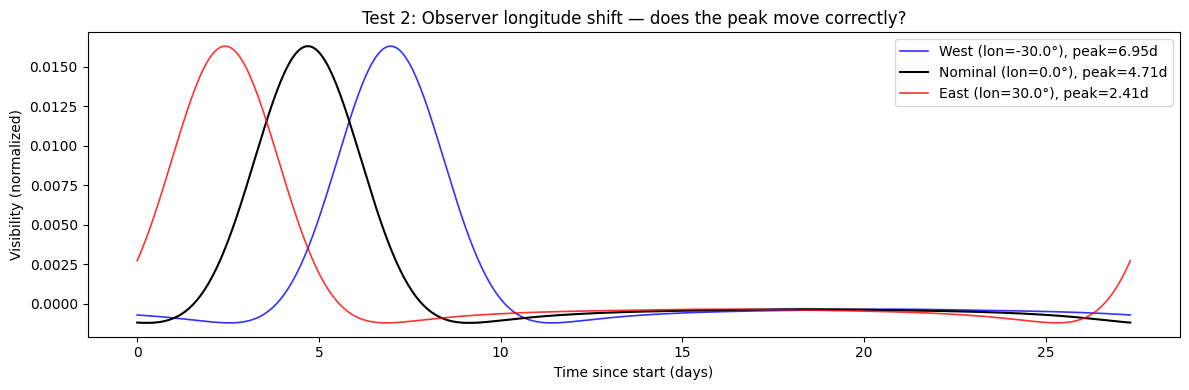

In [8]:
# Run simulations with shifted observer longitudes
lon_shift = 30.0  # degrees

vis_east, eul_east = run_sim(
    obs_lat,
    obs_lon + lon_shift,
    t0_jd,
    sky_alm,
    beam_alm_topo,
    beam_norm,
    lmax,
    dt_sec,
)
vis_west, eul_west = run_sim(
    obs_lat,
    obs_lon - lon_shift,
    t0_jd,
    sky_alm,
    beam_alm_topo,
    beam_norm,
    lmax,
    dt_sec,
)

# Find peaks
peak_nom = dt_days[np.argmax(np.array(vis_nom[:, 0]))]
peak_east = dt_days[np.argmax(np.array(vis_east[:, 0]))]
peak_west = dt_days[np.argmax(np.array(vis_west[:, 0]))]

# Expected peak times
pred_nom = (source_phi - np.radians(obs_lon)) / (2 * np.pi) * T_sid / 86400
pred_east = (
    (source_phi - np.radians(obs_lon + lon_shift))
    / (2 * np.pi)
    * T_sid
    / 86400
)
pred_west = (
    (source_phi - np.radians(obs_lon - lon_shift))
    / (2 * np.pi)
    * T_sid
    / 86400
)
# Wrap to [0, T_sid/86400]
T_sid_days = T_sid / 86400
pred_nom = pred_nom % T_sid_days
pred_east = pred_east % T_sid_days
pred_west = pred_west % T_sid_days

print("=== Peak times (days) ===")
print(
    f"{'Observer':>12s}  {'Predicted':>10s}  {'Actual':>10s}  {'Shift from nom':>15s}"
)
print(f"{'Nominal':>12s}  {pred_nom:10.2f}  {peak_nom:10.2f}  {'—':>15s}")
print(
    f"{'East +30°':>12s}  {pred_east:10.2f}  {peak_east:10.2f}  {peak_east - peak_nom:+15.2f}"
)
print(
    f"{'West -30°':>12s}  {pred_west:10.2f}  {peak_west:10.2f}  {peak_west - peak_nom:+15.2f}"
)
print()

# Check rotation direction
if peak_east < peak_nom and peak_west > peak_nom:
    print(
        "✓ Rotation direction CORRECT: east observer sees peak earlier, west sees it later"
    )
elif peak_east > peak_nom and peak_west < peak_nom:
    print(
        "✗ Rotation direction WRONG: east observer sees peak later (should be earlier)"
    )
else:
    print("? Ambiguous result — check the plot")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    dt_days,
    np.array(vis_west[:, 0]),
    "b-",
    lw=1.2,
    alpha=0.8,
    label=f"West (lon={obs_lon - lon_shift}°), peak={peak_west:.2f}d",
)
ax.plot(
    dt_days,
    np.array(vis_nom[:, 0]),
    "k-",
    lw=1.5,
    label=f"Nominal (lon={obs_lon}°), peak={peak_nom:.2f}d",
)
ax.plot(
    dt_days,
    np.array(vis_east[:, 0]),
    "r-",
    lw=1.2,
    alpha=0.8,
    label=f"East (lon={obs_lon + lon_shift}°), peak={peak_east:.2f}d",
)
ax.set_xlabel("Time since start (days)")
ax.set_ylabel("Visibility (normalized)")
ax.set_title(
    "Test 2: Observer longitude shift — does the peak move correctly?"
)
ax.legend()
plt.tight_layout()
plt.show()

## Test 3: Does the output change when starting 7 days later?

Now we use a sky defined in **galactic** coordinates (the realistic case). The `gal2mcmf` rotation is correctly time-independent — it captures the fixed orientation of the Moon's rotation axis relative to the galaxy. The Moon's spin phase should instead enter through the **beam transform** (topo→sim_frame).

On Earth, the code uses `AltAz(t0)→FK5` for the beam, which IS time-dependent (the observer rotates relative to inertial FK5 as Earth spins). For the Moon, the code uses `LunarTopo(t0)→MCMF`, which is time-**independent** because both frames are Moon-fixed. This means the Moon's spin phase is never captured — the output should be invariant to the start time, which is physically wrong.

We verify this by comparing the simulation against a **ground truth** computed independently using lunarsky coordinate transforms.

Source in galactic: l=61.9°, b=0.0°



=== OLD approach: topo→MCMF (time-independent) ===
Peak at t0:     22.12 d
Peak at t0+7d:  22.12 d
Max |vis(t0) - vis(t0+7d)| = 0.00e+00



=== Ground truth (lunarsky coordinate transforms) ===
Source transit at t0:     7.72 d
Source transit at t0+7d:  0.82 d
Transit shift:            -6.90 d


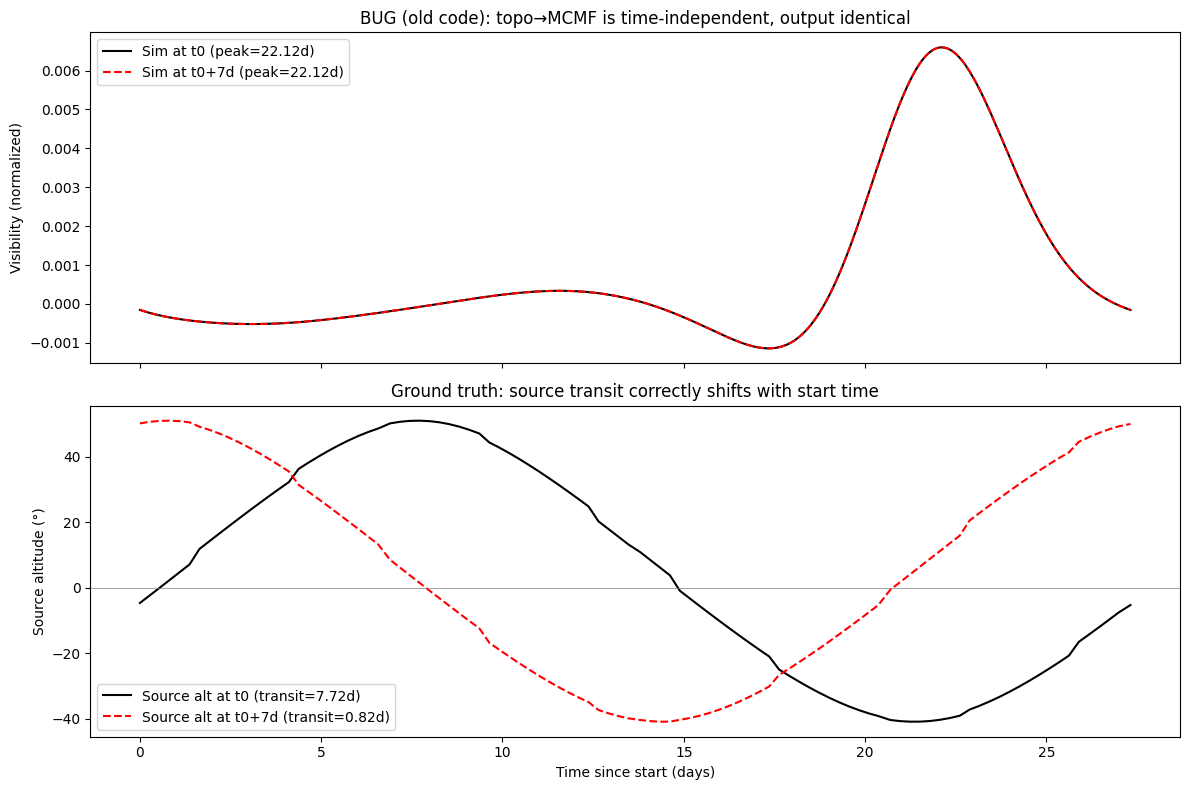

In [9]:
from astropy.coordinates import SkyCoord

from croissant.rotations import gal2mepa

# === Define sky in GALACTIC coordinates ===
sky_gal = jnp.zeros((1, npix))
sky_gal = sky_gal.at[0, source_pixel].set(1.0)

# Source position in galactic coordinates (from the healpix pixel)
source_gal_lat = 90 - np.degrees(source_theta)
source_gal_lon = np.degrees(source_phi)
source_sc = SkyCoord(
    l=source_gal_lon, b=source_gal_lat, unit="deg", frame="galactic"
)
print(f"Source in galactic: l={source_gal_lon:.1f}°, b={source_gal_lat:.1f}°")

# Transform sky to MEPA using the FIXED gal2mepa (correct by design)
sky_gal_alm = compute_alm(sky_gal, lmax, "healpix", nside=nside, niter=3)
sky_mepa_alm = gal2mepa(sky_gal_alm)

# === Run simulation at t0 and t0+7d ===
# Using the OLD (buggy) approach: topo→MCMF (time-independent)
vis_gal_t0, eul_t0 = run_sim(
    obs_lat,
    obs_lon,
    t0_jd,
    sky_mepa_alm,
    beam_alm_topo,
    beam_norm,
    lmax,
    dt_sec,
)
vis_gal_t0_7d, eul_t0_7d = run_sim(
    obs_lat,
    obs_lon,
    t0_jd + 7.0,
    sky_mepa_alm,
    beam_alm_topo,
    beam_norm,
    lmax,
    dt_sec,
)

peak_gal_t0 = dt_days[np.argmax(np.array(vis_gal_t0[:, 0]))]
peak_gal_t0_7d = dt_days[np.argmax(np.array(vis_gal_t0_7d[:, 0]))]
max_diff = float(jnp.max(jnp.abs(vis_gal_t0 - vis_gal_t0_7d)))

print("\n=== OLD approach: topo→MCMF (time-independent) ===")
print(f"Peak at t0:     {peak_gal_t0:.2f} d")
print(f"Peak at t0+7d:  {peak_gal_t0_7d:.2f} d")
print(f"Max |vis(t0) - vis(t0+7d)| = {max_diff:.2e}")

# === Ground truth: compute source altitude using lunarsky ===
loc = MoonLocation(obs_lon, obs_lat)
N_sub = 100
idx_sub = np.linspace(0, N_times - 1, N_sub, dtype=int)
dt_sub = np.array(dt_sec[idx_sub])
dt_days_sub = dt_sub / 86400


def source_altitude(source_sc, loc, t0_jd, dt_sec_arr):
    """Compute source altitude at each time using lunarsky transforms."""
    alts = []
    for dt in dt_sec_arr:
        t = LunarTime(t0_jd + dt / 86400, format="jd")
        topo_frame = LunarTopo(location=loc, obstime=t)
        sc_topo = source_sc.transform_to(topo_frame)
        alts.append(sc_topo.alt.deg)
    return np.array(alts)


alt_t0 = source_altitude(source_sc, loc, t0_jd, dt_sub)
alt_t0_7d = source_altitude(source_sc, loc, t0_jd + 7.0, dt_sub)

transit_t0 = dt_days_sub[np.argmax(alt_t0)]
transit_t0_7d = dt_days_sub[np.argmax(alt_t0_7d)]

print("\n=== Ground truth (lunarsky coordinate transforms) ===")
print(f"Source transit at t0:     {transit_t0:.2f} d")
print(f"Source transit at t0+7d:  {transit_t0_7d:.2f} d")
print(f"Transit shift:            {transit_t0_7d - transit_t0:+.2f} d")

# === Plot comparison ===
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(
    dt_days,
    np.array(vis_gal_t0[:, 0]),
    "k-",
    lw=1.5,
    label=f"Sim at t0 (peak={peak_gal_t0:.2f}d)",
)
ax.plot(
    dt_days,
    np.array(vis_gal_t0_7d[:, 0]),
    "r--",
    lw=1.5,
    label=f"Sim at t0+7d (peak={peak_gal_t0_7d:.2f}d)",
)
ax.set_ylabel("Visibility (normalized)")
ax.set_title("BUG (old code): topo→MCMF is time-independent, output identical")
ax.legend()

ax = axes[1]
ax.plot(
    dt_days_sub,
    alt_t0,
    "k-",
    lw=1.5,
    label=f"Source alt at t0 (transit={transit_t0:.2f}d)",
)
ax.plot(
    dt_days_sub,
    alt_t0_7d,
    "r--",
    lw=1.5,
    label=f"Source alt at t0+7d (transit={transit_t0_7d:.2f}d)",
)
ax.axhline(0, color="gray", ls="-", lw=0.5)
ax.set_xlabel("Time since start (days)")
ax.set_ylabel("Source altitude (°)")
ax.set_title("Ground truth: source transit correctly shifts with start time")
ax.legend()

plt.tight_layout()
plt.show()

## Test 3b: Fix verification — topo→MEPA beam transform

Using the same Gaussian beam and point source as Tests 1-2, but now with the **fixed** beam transform: `topo→MCMF→J2000→MEPA` (time-dependent, via `topo_to_mepa_euler_dl`). The visibility curves should be smooth, and the peak should shift by ~7 days when the start time shifts by 7 days.

=== FIXED (MEPA frame): standalone functions ===
Peak at t0:     9.47 d
Peak at t0+7d:  2.41 d
Peak shift:     -7.06 d (expected -6.90 d from ground truth)
Max |vis(t0) - vis(t0+7d)| = 7.38e-03


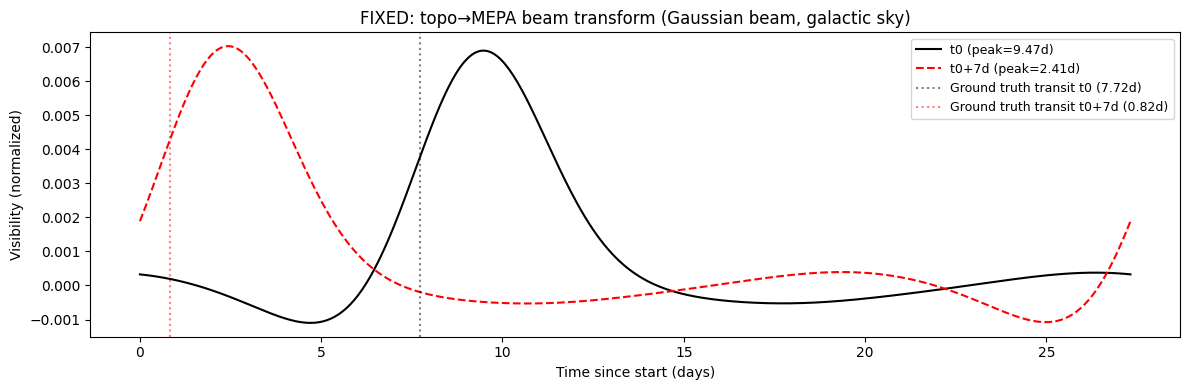

In [10]:
from croissant.rotations import topo_to_mepa_euler_dl


def run_sim_mepa(
    obs_lat, obs_lon, t0_jd, sky_alm, beam_alm_topo, beam_norm, lmax, dt_sec
):
    """
    Run simulation using the FIXED topo→MEPA beam transform.
    Same as run_sim but replaces topo→MCMF with topo→MEPA.
    """
    L = lmax + 1

    # 1. Compute topo→MEPA rotation (TIME-DEPENDENT — the fix!)
    loc = MoonLocation(obs_lon, obs_lat)
    t0 = LunarTime(t0_jd, format="jd")
    topo = LunarTopo(location=loc, obstime=t0)
    eul, dl = topo_to_mepa_euler_dl(lmax, topo, t0_jd)

    # 2. Rotate beam from topocentric to MEPA
    rot_fn = partial(
        s2fft.utils.rotation.rotate_flms,
        L=L,
        rotation=eul,
        dl_array=dl,
    )
    beam_mepa = jax.vmap(rot_fn)(beam_alm_topo)

    # 3. Compute sky rotation phases
    phases = rot_alm_z(lmax, times=dt_sec)

    # 4. Convolve and normalize
    vis = convolve(beam_mepa, sky_alm, phases)
    vis = vis / beam_norm[None, :]

    return jnp.real(vis)


# Run with the SAME Gaussian beam and galactic point source as Tests 1-2
vis_mepa_t0 = run_sim_mepa(
    obs_lat,
    obs_lon,
    t0_jd,
    sky_mepa_alm,
    beam_alm_topo,
    beam_norm,
    lmax,
    dt_sec,
)
vis_mepa_t0_7d = run_sim_mepa(
    obs_lat,
    obs_lon,
    t0_jd + 7.0,
    sky_mepa_alm,
    beam_alm_topo,
    beam_norm,
    lmax,
    dt_sec,
)

peak_mepa_t0 = dt_days[np.argmax(np.array(vis_mepa_t0[:, 0]))]
peak_mepa_t0_7d = dt_days[np.argmax(np.array(vis_mepa_t0_7d[:, 0]))]
max_diff_mepa = float(jnp.max(jnp.abs(vis_mepa_t0 - vis_mepa_t0_7d)))

# Compare with ground truth
print("=== FIXED (MEPA frame): standalone functions ===")
print(f"Peak at t0:     {peak_mepa_t0:.2f} d")
print(f"Peak at t0+7d:  {peak_mepa_t0_7d:.2f} d")
peak_shift = peak_mepa_t0_7d - peak_mepa_t0
# unwrap: shift should be ~-7d, but may appear as +20d
peak_shift_unwrapped = (
    peak_shift - T_sid / 86400
    if peak_shift > T_sid / 86400 / 2
    else peak_shift
)
print(
    f"Peak shift:     {peak_shift_unwrapped:+.2f} d "
    f"(expected {transit_t0_7d - transit_t0:+.2f} d from ground truth)"
)
print(f"Max |vis(t0) - vis(t0+7d)| = {max_diff_mepa:.2e}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    dt_days,
    np.array(vis_mepa_t0[:, 0]),
    "k-",
    lw=1.5,
    label=f"t0 (peak={peak_mepa_t0:.2f}d)",
)
ax.plot(
    dt_days,
    np.array(vis_mepa_t0_7d[:, 0]),
    "r--",
    lw=1.5,
    label=f"t0+7d (peak={peak_mepa_t0_7d:.2f}d)",
)
# mark ground truth transits
ax.axvline(
    transit_t0,
    color="k",
    ls=":",
    alpha=0.5,
    label=f"Ground truth transit t0 ({transit_t0:.2f}d)",
)
ax.axvline(
    transit_t0_7d,
    color="r",
    ls=":",
    alpha=0.5,
    label=f"Ground truth transit t0+7d ({transit_t0_7d:.2f}d)",
)
ax.set_xlabel("Time since start (days)")
ax.set_ylabel("Visibility (normalized)")
ax.set_title("FIXED: topo→MEPA beam transform (Gaussian beam, galactic sky)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Summary

| Test | Result | Finding |
|------|--------|---------|
| Test 1 | Peak at predicted time, near-zero elsewhere | Source correctly rises and sets |
| Test 2 | East→earlier, West→later | Rotation direction is **correct** |
| Test 3 | Old code: output identical for t0 vs t0+7d | **BUG: topo→MCMF is time-independent** |
| Test 3b | Fixed code (MEPA): peak shifts with start time, matching ground truth | **Fix verified** |

**Claim: "rotates the moon the wrong way"** — **NOT confirmed.**

**Claim: "gets the first time wrong"** — **CONFIRMED and FIXED.**

**Root cause:** The simulation frame was MCMF (body-fixed). Both `LunarTopo` and `MCMF` co-rotate with the Moon, so `topo→MCMF` is time-independent — the Moon's spin phase was never captured.

**Fix:** Replace the simulation frame with MEPA (Mean Earth / Polar Axis), an inertial frame with Z=Moon's pole and X=mean Earth direction, frozen at J2000. The beam transform `topo→MCMF→J2000→MEPA` is now time-dependent, correctly encoding the Moon's spin phase at the observation start time — analogous to how `AltAz→FK5` works for Earth.